# Вывод волнового уравнения для прямоугольного MenDrive резонатора

геометрия задачи следующая: 

поверхность хорошего проводника $x<=-a$

вакуум внутри резонатора заполняет область $-a<=x<=a$

В области $x>a$ - плохой проводник


перейдём к **полному трёхмерному случаю** с учётом зависимости от $y$, а затем частный случай $k_y = 0$ будет получаться автоматически.

---

## 🔹 Цель

Переписать вывод волновых уравнений для **TE/TM мод** в прямоугольном резонаторе с идеальными проводниками на $y = -b$ и $y = b$, используя **SageMath + дифференциальную геометрию**, чтобы:

1. Автоматизировать проверку ваших аналитических выкладок.
2. Получить общую форму волновых уравнений при $k_y \ne 0$.
3. Убедиться, что при $k_y = 0$ воспроизводится ваш текущий результат.
4. Подготовить основу для дальнейшего расчёта пондеромоторной силы.

---

## 🔹 Шаг 1: Геометрия и гармоническая зависимость

Мы задаём поле в виде:

$$
\vec{E}(x, y, z, t) = \vec{E}(x, y)\, e^{i(k_z z - \omega t)}, \quad
\vec{H}(x, y, z, t) = \vec{H}(x, y)\, e^{i(k_z z - \omega t)}
$$

Теперь **разрешаем зависимость от $y$**, но по-прежнему предполагаем однородность в $z$ (только фазовый множитель).

---

## 🔹 Шаг 2: Граничные условия по $y$

На $y = -b$ и $y = b$ — **идеальный проводник (PEC)**:

- Для **TM-моды** ($H_z = 0$):  
  $$
  E_z(x, y=-b) = E_z(x, y=b) = 0 \quad \Rightarrow \quad
  $$
  
  $E_z \propto \cos(k_y y), k_y = \frac{(2m+1)\pi}{2b},\ m = 0,1,2,\dots$
 
  $E_z \propto \sin(k_y y), k_y = \frac{(m+1)\pi}{b},\ m = 0, 1,2,\dots$


0 0
0 0


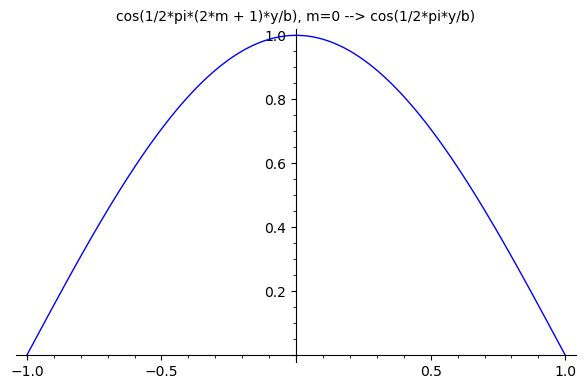

0 0
0 0


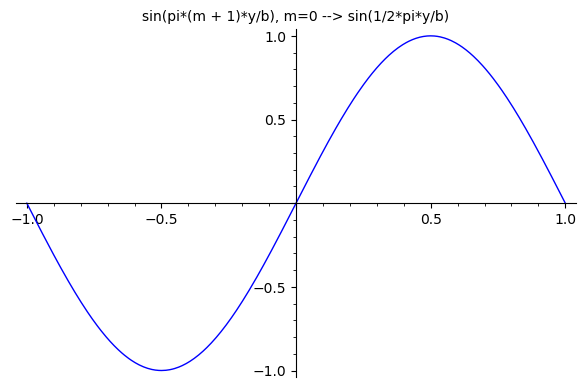

1 0
1 0


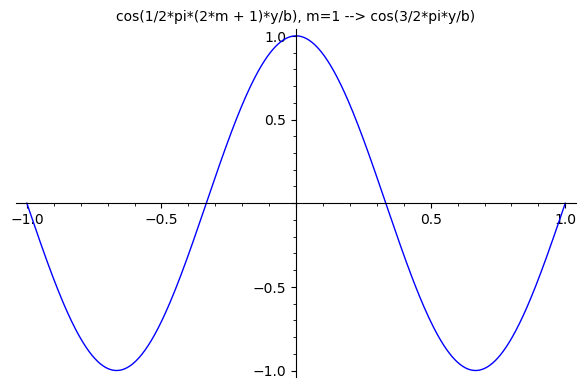

1 0
1 0


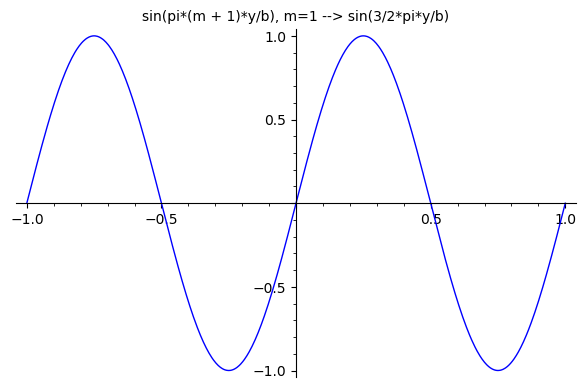

In [1]:
var("m b y")
ky_TM_cos = (1+2*m)*pi/(2*b)
ky_TM_sin = (1+m)*pi/(b)
TM_Ez_cos = cos(ky_TM_cos*y)
TM_Ez_sin = sin(ky_TM_sin*y)
b_val = 1
for m_val in range (0, 2):
    print(m_val, TM_Ez_cos.subs(y == b , m == m_val))
    print(m_val, TM_Ez_cos.subs(y == -b , m == m_val))
    plot(TM_Ez_cos.subs(b == b_val, m == m_val), y, -b_val, b_val).show(
        title=f"cos({ky_TM_cos*y}), m={m_val} --> cos({ky_TM_cos.subs(m==m_val)*y})")
    print(m_val, TM_Ez_sin.subs(y == b , m == m_val))
    print(m_val, TM_Ez_sin.subs(y == -b , m == m_val))
    plot(TM_Ez_sin.subs(b == b_val, m == m_val), y, -b_val, b_val).show(
        title=f"sin({ky_TM_sin*y}), m={m_val} --> sin({ky_TM_cos.subs(m==m_val)*y})")


- Для **TE-моды** ($E_z = 0$):  
  $$
  \frac{\partial H_z}{\partial y}\bigg|_{y=-b,b} = 0 \quad \Rightarrow \quad
  $$

  $ H_z \propto \sin(k_y y) k_y = \dfrac{\left(2m+1\right)\pi}{2 b},\ m = 0,1,2,\dots$

  $ H_z \propto \cos(k_y y) k_y = \dfrac{\left(2m+1\right)\pi}{b},\ m = 0,1,2,\dots$

> Это **квантование** $k_y$, но мы пока оставляем его как параметр `k_y`.

0 1
0 -1


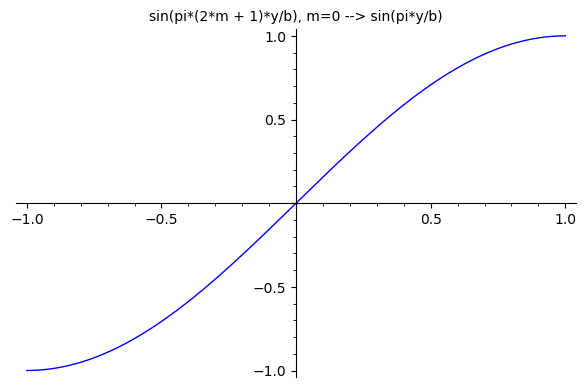

0 -1
0 -1


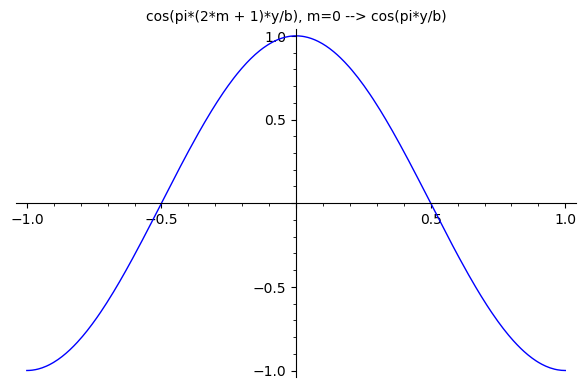

1 -1
1 1


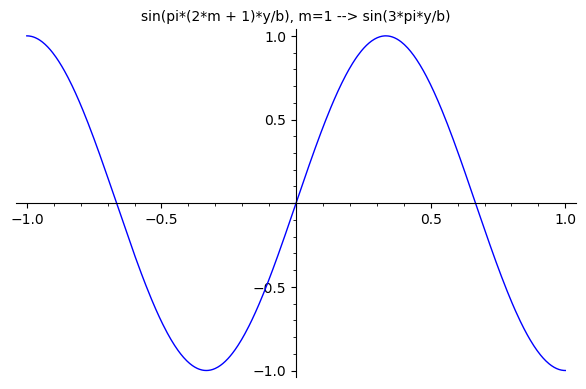

1 -1
1 -1


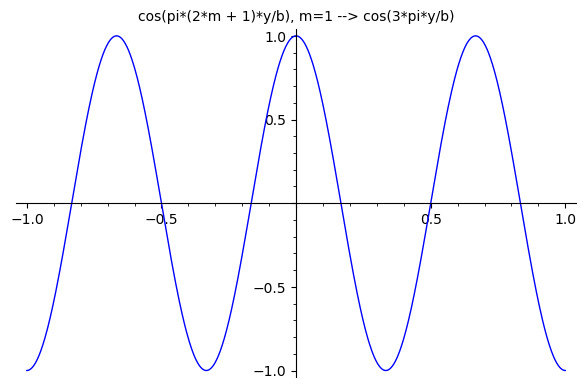

In [2]:
var("m b y")
ky_TE_sin = (2*m+1)*pi/(2*b)
ky_TE_cos = (2*m+1)*pi/(b)
TE_Hz_sin = sin(ky_TE_sin*y)
TE_Hz_cos = cos(ky_TE_cos*y)
b_val = 1
for m_val in range (0, 2):
    print(m_val, TE_Hz_sin.subs(y == b , m == m_val))
    print(m_val, TE_Hz_sin.subs(y == -b , m == m_val))
    plot(TE_Hz_sin.subs(b == b_val, m == m_val), y, -b_val, b_val).show(
        title=f"sin({ky_TE_cos*y}), m={m_val} --> sin({ky_TE_cos.subs(m==m_val)*y})")
    print(m_val, TE_Hz_cos.subs(y == b , m == m_val))
    print(m_val, TE_Hz_cos.subs(y == -b , m == m_val))
    plot(TE_Hz_cos.subs(b == b_val, m == m_val), y, -b_val, b_val).show(
        title=f"cos({ky_TE_cos*y}), m={m_val} --> cos({ky_TE_cos.subs(m==m_val)*y})")

## 🔹 Шаг 3: Код на SageMath с зависимостью от $y$

In [3]:
# Создаём евклидово пространство
Eu.<x, y, z> = EuclideanSpace(coordinates='Cartesian')

# Параметры
var('t omega c k_z k_y')
assume(omega, 'complex', c > 0, k_z, 'real', k_y, 'real')  # ky может быть комплексным, но для PEC — вещественный

# Фазовый множитель
phase_y = exp(I * (k_y * y))
phase = exp(I * (k_z * z - omega * t)) * phase_y

# Компоненты полей (зависят от x и y!)
Ex = function('Ex')(x, y)
Ey = function('Ey')(x, y)
Ez = function('Ez')(x, y)
E_x = function('E_x')(x)
E_y = function('E_y')(x)
E_z = function('E_z')(x)# * cos(k_y * y)

Hx = function('Hx')(x, y)
Hy = function('Hy')(x, y)
Hz = function('Hz')(x, y)
H_x = function('H_x')(x)
H_y = function('H_y')(x)
H_z = function('H_z')(x)# * sin(k_y * y)

# Полные векторные поля
E_vec = Eu.vector_field(E_x * phase, E_y * phase, E_z * phase, name='E')
H_vec = Eu.vector_field(H_x * phase, H_y * phase, H_z * phase, name='H')

In [4]:
E = matrix([[E_x * phase],
            [E_y * phase],
            [E_z * phase]])
show(E)

[E_x(x)*e^(-I*omega*t + I*k_y*y + I*k_z*z)]
[E_y(x)*e^(-I*omega*t + I*k_y*y + I*k_z*z)]
[E_z(x)*e^(-I*omega*t + I*k_y*y + I*k_z*z)]

In [5]:
H = matrix([[H_x * phase],
            [H_y * phase],
            [H_z * phase]])
show(H)

[H_x(x)*e^(-I*omega*t + I*k_y*y + I*k_z*z)]
[H_y(x)*e^(-I*omega*t + I*k_y*y + I*k_z*z)]
[H_z(x)*e^(-I*omega*t + I*k_y*y + I*k_z*z)]

## 🔹 Шаг 4: Тензоры проницаемости (диагональные или нет)

In [6]:
# Диагональные тензоры (можно расширить до недиагональных)
epsilon_xx, epsilon_yy, epsilon_zz = var('epsilon_xx epsilon_yy epsilon_zz', domain='complex')
mu_xx, mu_yy, mu_zz                = var('mu_xx mu_yy mu_zz', domain='complex')

In [7]:
# Тензор epsilon' _anisotropic
epsilon = matrix([
    [epsilon_xx,         0,      0],
    [        0, epsilon_yy,      0],
    [        0,      0, epsilon_zz]
])

show(epsilon)

[epsilon_xx          0          0]
[         0 epsilon_yy          0]
[         0          0 epsilon_zz]

In [8]:
# _anisotropic
mu = matrix([
    [mu_xx,     0,     0],
    [0,     mu_yy,     0],
    [0,         0, mu_zz],
])
show(mu)

[mu_xx     0     0]
[    0 mu_yy     0]
[    0     0 mu_zz]

In [9]:
D = epsilon*E
show(D)

[epsilon_xx*E_x(x)*e^(-I*omega*t + I*k_y*y + I*k_z*z)]
[epsilon_yy*E_y(x)*e^(-I*omega*t + I*k_y*y + I*k_z*z)]
[epsilon_zz*E_z(x)*e^(-I*omega*t + I*k_y*y + I*k_z*z)]

In [10]:
B = mu*H
show(B)

[mu_xx*H_x(x)*e^(-I*omega*t + I*k_y*y + I*k_z*z)]
[mu_yy*H_y(x)*e^(-I*omega*t + I*k_y*y + I*k_z*z)]
[mu_zz*H_z(x)*e^(-I*omega*t + I*k_y*y + I*k_z*z)]

In [11]:
# Диэлектрическое смещение D = eps * E
# Магнитная индукция B = mu * H
D_vec = Eu.vector_field(D[0][0], D[1][0], D[2][0], name='D')
B_vec = Eu.vector_field(B[0][0], B[1][0], B[2][0], name='B')

## 🔹 Шаг 5: Уравнения Максвелла в частотной области

Шаг 4: Компонентные уравнения

In [12]:
from sage.manifolds.operators import curl, div, grad, laplacian

# Роторы
curl_E = curl(E_vec)      # =  i ω/c * B
curl_H = curl(H_vec)      # = -i ω/c * D

# Правые части
rhs_eq_rot_E =  I * omega / c * B_vec
rhs_eq_rot_H = -I * omega / c * D_vec

show(rhs_eq_rot_E[1].expr())
show(rhs_eq_rot_E[2].expr())
show(rhs_eq_rot_E[3].expr())

show(rhs_eq_rot_H[1].expr())
show(rhs_eq_rot_H[2].expr())
show(rhs_eq_rot_H[3].expr())

I*mu_xx*omega*H_x(x)*e^(-I*omega*t + I*k_y*y + I*k_z*z)/c

I*mu_yy*omega*H_y(x)*e^(-I*omega*t + I*k_y*y + I*k_z*z)/c

I*mu_zz*omega*H_z(x)*e^(-I*omega*t + I*k_y*y + I*k_z*z)/c

-I*epsilon_xx*omega*E_x(x)*e^(-I*omega*t + I*k_y*y + I*k_z*z)/c

-I*epsilon_yy*omega*E_y(x)*e^(-I*omega*t + I*k_y*y + I*k_z*z)/c

-I*epsilon_zz*omega*E_z(x)*e^(-I*omega*t + I*k_y*y + I*k_z*z)/c

In [13]:
# Компонентные уравнения
eq_rot_E = []
eq_rot_H = []
for i in range(1, 4):
    eq1 = (curl_E[i].expr() == rhs_eq_rot_E[i].expr()).simplify_full()
    eq2 = (curl_H[i].expr() == rhs_eq_rot_H[i].expr()).simplify_full()
    # Делим обе части на phase (≠ 0)
    eq_rot_E.append(eq1.lhs() / phase == eq1.rhs() / phase)
    eq_rot_H.append(eq2.lhs() / phase == eq2.rhs() / phase)

# eqs[0] → (∂Ez/∂y - ∂Ey/∂z) = i ω/c μ_xx Hx → -i ky Ez - i kz Ey = i ω/c μ_xx Hx
# и т.д.

In [14]:
show(eq_rot_E)

[-I*k_z*E_y(x) + I*k_y*E_z(x) == I*mu_xx*omega*H_x(x)/c,
 I*k_z*E_x(x) - diff(E_z(x), x) == I*mu_yy*omega*H_y(x)/c,
 -I*k_y*E_x(x) + diff(E_y(x), x) == I*mu_zz*omega*H_z(x)/c]

In [15]:
show(eq_rot_H)

[-I*k_z*H_y(x) + I*k_y*H_z(x) == -I*epsilon_xx*omega*E_x(x)/c,
 I*k_z*H_x(x) - diff(H_z(x), x) == -I*epsilon_yy*omega*E_y(x)/c,
 -I*k_y*H_x(x) + diff(H_y(x), x) == -I*epsilon_zz*omega*E_z(x)/c]

In [16]:
def get_field(eq_rot_E, eq_rot_H, eq_rot_E_index, eq_rot_H_index, field_for_exclude, field_for_solve):
    # Группируем уравнения в пары,
    # удобные для исключения переменных поля в левой части
    excluding_1 = solve(eq_rot_E[eq_rot_E_index], field_for_exclude)
    excluding_2 = solve(eq_rot_H[eq_rot_H_index], field_for_exclude)
    if len(excluding_1) > 0 and len(excluding_2):
        # Получаем выражение для поперечных
        # (по отношению к оси волновода z)
        # компонент поля через продольные
        return (solve(
            excluding_1[0].rhs() == \
            excluding_2[0].rhs(),
        field_for_solve))[0]

In [17]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 0
eq_rot_H_index = 1
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
field_for_exclude = H_x(x=x)
field_for_solve   = E_y(x=x)

E_sb_y = get_field(eq_rot_E, eq_rot_H,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(E_sb_y)

E_y(x) == (c^2*k_y*k_z*E_z(x) + I*c*mu_xx*omega*diff(H_z(x), x))/(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)

In [18]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 0
eq_rot_H_index = 1
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
field_for_exclude = E_y(x=x)
field_for_solve   = H_x(x=x)

H_sb_x = get_field(eq_rot_E, eq_rot_H,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(H_sb_x)

H_x(x) == -(c*epsilon_yy*k_y*omega*E_z(x) + I*c^2*k_z*diff(H_z(x), x))/(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)

In [19]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 1
eq_rot_H_index = 0
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
field_for_exclude = H_y(x=x)
field_for_solve   = E_x(x=x)

E_sb_x = get_field(eq_rot_E, eq_rot_H,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(E_sb_x)

E_x(x) == (c*k_y*mu_yy*omega*H_z(x) - I*c^2*k_z*diff(E_z(x), x))/(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)

In [20]:
# Группируем уравнения в пары, удобные для исключения переменных поля в левой части
eq_rot_E_index = 1
eq_rot_H_index = 0
# Получаем выражение для поперечных (по отношению к оси волновода z) компонент поля через продольные
field_for_exclude = E_x(x=x)
field_for_solve   = H_y(x=x)

H_sb_y = get_field(eq_rot_E, eq_rot_H,
                                eq_rot_E_index, eq_rot_H_index,
                                field_for_exclude, field_for_solve)
show(H_sb_y)

H_y(x) == (c^2*k_y*k_z*H_z(x) - I*c*epsilon_xx*omega*diff(E_z(x), x))/(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)

In [21]:
# ------------------------------------------------------------
# 3. Роторы → уравнения Максвелла
# ------------------------------------------------------------
curl_E = curl(E_vec)      # = i ω/c * B
curl_H = curl(H_vec)      # = -i ω/c * D

In [22]:
# ------------------------------------------------------------
# 4. Двойной ротор: ∇ × (∇ × E)
# ------------------------------------------------------------
curl_curl_E = curl(curl_E)

show(curl_curl_E[:])

[((k_y^2 + k_z^2)*E_x(x) + I*k_y*d(E_y)/dx + I*k_z*d(E_z)/dx)*e^(-I*omega*t + I*k_y*y + I*k_z*z),
 (k_z^2*E_y(x) - k_y*k_z*E_z(x) + I*k_y*d(E_x)/dx - d^2(E_y)/dx^2)*e^(-I*omega*t + I*k_y*y + I*k_z*z),
 -(k_y*k_z*E_y(x) - k_y^2*E_z(x) - I*k_z*d(E_x)/dx + d^2(E_z)/dx^2)*e^(-I*omega*t + I*k_y*y + I*k_z*z)]

$$rot\,rot\,\vec{E} = grad\,div\,\vec{E} - Laplasian\,\vec{E}$$

In [23]:
grad_div_E = grad(div(E_vec))
laplacian_E = laplacian(E_vec)
grad_div_laplacian_E = grad_div_E - laplacian_E

In [24]:
show(div(E_vec).expr())

(I*k_y*E_y(x) + I*k_z*E_z(x) + diff(E_x(x), x))*e^(-I*omega*t + I*k_y*y + I*k_z*z)

In [25]:
show(grad_div_E[3])

-(k_y*k_z*E_y(x) + k_z^2*E_z(x) - I*k_z*d(E_x)/dx)*e^(-I*omega*t + I*k_y*y + I*k_z*z)

In [26]:
show(laplacian_E[3])

-((k_y^2 + k_z^2)*E_z(x) - d^2(E_z)/dx^2)*e^(-I*omega*t + I*k_y*y + I*k_z*z)

In [27]:
show(grad_div_laplacian_E[3])

-(k_y*k_z*E_y(x) - k_y^2*E_z(x) - I*k_z*d(E_x)/dx + d^2(E_z)/dx^2)*e^(-I*omega*t + I*k_y*y + I*k_z*z)

In [28]:
# Аналогично для H
curl_curl_H = curl(curl_H)

show(curl_curl_H[:])

[((k_y^2 + k_z^2)*H_x(x) + I*k_y*d(H_y)/dx + I*k_z*d(H_z)/dx)*e^(-I*omega*t + I*k_y*y + I*k_z*z),
 (k_z^2*H_y(x) - k_y*k_z*H_z(x) + I*k_y*d(H_x)/dx - d^2(H_y)/dx^2)*e^(-I*omega*t + I*k_y*y + I*k_z*z),
 -(k_y*k_z*H_y(x) - k_y^2*H_z(x) - I*k_z*d(H_x)/dx + d^2(H_z)/dx^2)*e^(-I*omega*t + I*k_y*y + I*k_z*z)]

Применяя к первому уравнению из этой пары операцию ротора

$$rot\,rot\,\vec{E} =  \frac{i\,\omega}{c} \, rot\left(\mu'\,\vec{H}\right)$$

In [29]:
rot_B = curl(B_vec) - mu_xx*(curl(H_vec) - rhs_eq_rot_H)
show( I * omega / c * rot_B[3] )

I*(-I*epsilon_zz*mu_xx*omega*E_z(x) - (c*mu_xx - c*mu_yy)*d(H_y)/dx)*omega*e^(-I*omega*t + I*k_y*y + I*k_z*z)/c^2

In [30]:
# Подставляем ∇ × H = -i ω/c D → ∇ × B = μ ∇ × H = -i ω/c μ ε E
# Но делаем это явно:
rhs_curl_curl_E = I * omega / c * rot_B
show(rhs_curl_curl_E[:])

[(epsilon_xx*mu_xx*omega^2*E_x(x) - (c*k_z*mu_xx - c*k_z*mu_yy)*omega*H_y(x) + (c*k_y*mu_xx - c*k_y*mu_zz)*omega*H_z(x))*e^(-I*omega*t + I*k_y*y + I*k_z*z)/c^2,
 (epsilon_yy*mu_xx*omega^2*E_y(x) - (-I*c*mu_xx + I*c*mu_zz)*omega*d(H_z)/dx)*e^(-I*omega*t + I*k_y*y + I*k_z*z)/c^2,
 (epsilon_zz*mu_xx*omega^2*E_z(x) + (-I*c*mu_xx + I*c*mu_yy)*omega*d(H_y)/dx)*e^(-I*omega*t + I*k_y*y + I*k_z*z)/c^2]

Применяя ко второму уравнению из этой пары операцию ротора

$$rot \, rot\,\vec{H} = - \frac{i\,\omega}{c} rot \left( \epsilon'  \vec E\right)$$

In [31]:
rot_D = curl(D_vec) - epsilon_xx * (curl(E_vec) - rhs_eq_rot_E)
show((-I * omega / c * rot_D[3]))

-I*(I*epsilon_xx*mu_zz*omega*H_z(x) - (c*epsilon_xx - c*epsilon_yy)*d(E_y)/dx)*omega*e^(-I*omega*t + I*k_y*y + I*k_z*z)/c^2

In [32]:
# Аналогично для H
curl_curl_H = curl(curl_H)
rhs_curl_curl_H = -I * omega / c * rot_D
show(rhs_curl_curl_H[:])

[(epsilon_xx*mu_xx*omega^2*H_x(x) + (c*epsilon_xx - c*epsilon_yy)*k_z*omega*E_y(x) - (c*epsilon_xx - c*epsilon_zz)*k_y*omega*E_z(x))*e^(-I*omega*t + I*k_y*y + I*k_z*z)/c^2,
 (epsilon_xx*mu_yy*omega^2*H_y(x) + (-I*c*epsilon_xx + I*c*epsilon_zz)*omega*d(E_z)/dx)*e^(-I*omega*t + I*k_y*y + I*k_z*z)/c^2,
 (epsilon_xx*mu_zz*omega^2*H_z(x) - (-I*c*epsilon_xx + I*c*epsilon_yy)*omega*d(E_y)/dx)*e^(-I*omega*t + I*k_y*y + I*k_z*z)/c^2]

In [33]:
# Упрощаем обе части, деля на phase
lhs_ccE = [comp / phase for comp in curl_curl_E[:]]
rhs_ccE = [comp / phase for comp in rhs_curl_curl_E[:]]
show(lhs_ccE)
show(lhs_ccE)

[(k_y^2 + k_z^2)*E_x(x) + I*k_y*d(E_y)/dx + I*k_z*d(E_z)/dx,
 k_z^2*E_y(x) - k_y*k_z*E_z(x) + I*k_y*d(E_x)/dx - d^2(E_y)/dx^2,
 -k_y*k_z*E_y(x) + k_y^2*E_z(x) + I*k_z*d(E_x)/dx - d^2(E_z)/dx^2]

[(k_y^2 + k_z^2)*E_x(x) + I*k_y*d(E_y)/dx + I*k_z*d(E_z)/dx,
 k_z^2*E_y(x) - k_y*k_z*E_z(x) + I*k_y*d(E_x)/dx - d^2(E_y)/dx^2,
 -k_y*k_z*E_y(x) + k_y^2*E_z(x) + I*k_z*d(E_x)/dx - d^2(E_z)/dx^2]

In [34]:
# Аналогично для H
lhs_ccH = [comp / phase for comp in curl_curl_H[:]]
rhs_ccH = [comp / phase for comp in rhs_curl_curl_H[:]]
show(lhs_ccH)
show(rhs_ccH)

[(k_y^2 + k_z^2)*H_x(x) + I*k_y*d(H_y)/dx + I*k_z*d(H_z)/dx,
 k_z^2*H_y(x) - k_y*k_z*H_z(x) + I*k_y*d(H_x)/dx - d^2(H_y)/dx^2,
 -k_y*k_z*H_y(x) + k_y^2*H_z(x) + I*k_z*d(H_x)/dx - d^2(H_z)/dx^2]

[(epsilon_xx*mu_xx*omega^2*H_x(x) + (c*epsilon_xx - c*epsilon_yy)*k_z*omega*E_y(x) - (c*epsilon_xx - c*epsilon_zz)*k_y*omega*E_z(x))/c^2,
 (epsilon_xx*mu_yy*omega^2*H_y(x) + (-I*c*epsilon_xx + I*c*epsilon_zz)*omega*d(E_z)/dx)/c^2,
 (epsilon_xx*mu_zz*omega^2*H_z(x) - (-I*c*epsilon_xx + I*c*epsilon_yy)*omega*d(E_y)/dx)/c^2]

In [35]:
# ------------------------------------------------------------
# 5. Выбираем уравнение для продольной компоненты (TM: Ez, TE: Hz)
# ------------------------------------------------------------

In [36]:
# Для TM-волны: Hz = 0 → работаем с Ez
# Берём z-компоненту двойного ротора:
eq_TM = lhs_ccE[2].expr() - rhs_ccE[2].expr() == 0
show(eq_TM)

-k_y*k_z*E_y(x) + k_y^2*E_z(x) + I*k_z*diff(E_x(x), x) - (epsilon_zz*mu_xx*omega^2*E_z(x) + (-I*c*mu_xx + I*c*mu_yy)*omega*diff(H_y(x), x))/c^2 - diff(E_z(x), x, x) == 0

In [37]:
# Для TE-волны: Ez = 0 → работаем с Hz
# Берём z-компоненту двойного ротора:
eq_TE = lhs_ccH[2].expr() - rhs_ccH[2].expr() == 0
show(eq_TE)

-k_y*k_z*H_y(x) + k_y^2*H_z(x) + I*k_z*diff(H_x(x), x) - (epsilon_xx*mu_zz*omega^2*H_z(x) - (-I*c*epsilon_xx + I*c*epsilon_yy)*omega*diff(E_y(x), x))/c^2 - diff(H_z(x), x, x) == 0

## 🔹 Шаг 6: Исключение поперечных компонент → волновое уравнение

Подставляем выражение для поперечных компонент

### Для TE-моды ($E_z = 0$):

$$\frac{\partial^{2}}{(\partial {x})^{2}}{H_z}(x,y) + K_{x,TE}^2\,{H_z}(x,y) = 0$$

In [38]:
eq_TE = eq_TE \
    .substitute_function(E_sb_y) \
    .substitute_function(E_sb_x) \
    .substitute_function(H_sb_y) \
    .substitute_function(H_sb_x) \
    .expand()
show(eq_TE)

-c^2*k_y^2*k_z^2*H_z(x)/(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2) - I*c*epsilon_xx*k_y*k_z*omega*diff(E_z(x), x)/(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2) + I*c*epsilon_xx*k_y*k_z*omega*diff(E_z(x), x)/(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2) + c^2*k_z^2*diff(H_z(x), x, x)/(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2) + epsilon_xx*mu_xx*omega^2*diff(H_z(x), x, x)/(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2) - epsilon_yy*mu_xx*omega^2*diff(H_z(x), x, x)/(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2) + k_y^2*H_z(x) - epsilon_xx*mu_zz*omega^2*H_z(x)/c^2 - diff(H_z(x), x, x) == 0

In [39]:
eq_TE_k_Hz = eq_TE.lhs().coefficient(H_z).factor()
show(eq_TE_k_Hz)

-(c^2*k_y^2*mu_yy + c^2*k_z^2*mu_zz - epsilon_xx*mu_yy*mu_zz*omega^2)*epsilon_xx*omega^2/((c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)*c^2)

In [40]:
eq_TE_k_d2Hz_dx2 = eq_TE.lhs().coefficient(diff(H_z(x=x),x,2)).factor()
show(eq_TE_k_d2Hz_dx2)

epsilon_xx*mu_xx*omega^2/(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)

In [41]:
K2_x_TE = (eq_TE_k_Hz/eq_TE_k_d2Hz_dx2)
show(K2_x_TE)

-(c^2*k_y^2*mu_yy + c^2*k_z^2*mu_zz - epsilon_xx*mu_yy*mu_zz*omega^2)*(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)/((c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)*c^2*mu_xx)

In [42]:
K2_x_TE

-(c^2*k_y^2*mu_yy + c^2*k_z^2*mu_zz - epsilon_xx*mu_yy*mu_zz*omega^2)*(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)/((c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)*c^2*mu_xx)

In [43]:
show(K2_x_TE.subs(k_y == 0).factor().expand())

-k_z^2*mu_zz/mu_xx + epsilon_yy*mu_zz*omega^2/c^2

### Для TM-моды ($H_z = 0$):

$$\frac{\partial^{2}}{(\partial {x})^{2}}{E_z}(x,y) + K_{x,TM}^2\,{E_z}(x,y) = 0$$

In [44]:
eq_TM = eq_TM \
    .substitute_function(E_sb_y) \
    .substitute_function(E_sb_x) \
    .substitute_function(H_sb_y) \
    .substitute_function(H_sb_x) \
    .expand()
show(eq_TM)

-c^2*k_y^2*k_z^2*E_z(x)/(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2) - I*c*k_y*k_z*mu_xx*omega*diff(H_z(x), x)/(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2) + I*c*k_y*k_z*mu_xx*omega*diff(H_z(x), x)/(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2) + c^2*k_z^2*diff(E_z(x), x, x)/(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2) + epsilon_xx*mu_xx*omega^2*diff(E_z(x), x, x)/(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2) - epsilon_xx*mu_yy*omega^2*diff(E_z(x), x, x)/(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2) + k_y^2*E_z(x) - epsilon_zz*mu_xx*omega^2*E_z(x)/c^2 - diff(E_z(x), x, x) == 0

In [45]:
eq_TM_k_Ez = eq_TM.lhs().coefficient(E_z).factor()
show(eq_TM_k_Ez)

-(c^2*epsilon_yy*k_y^2 + c^2*epsilon_zz*k_z^2 - epsilon_yy*epsilon_zz*mu_xx*omega^2)*mu_xx*omega^2/((c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)*c^2)

In [46]:
eq_TM_k_d2Ez_dx2 = eq_TM.lhs().coefficient(diff(E_z(x=x),x,2)).factor()
show(eq_TM_k_d2Ez_dx2)

epsilon_xx*mu_xx*omega^2/(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)

In [47]:
K2_x_TM = (eq_TM_k_Ez/eq_TM_k_d2Ez_dx2)
show(K2_x_TM)

-(c^2*epsilon_yy*k_y^2 + c^2*epsilon_zz*k_z^2 - epsilon_yy*epsilon_zz*mu_xx*omega^2)*(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)/((c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)*c^2*epsilon_xx)

In [48]:
K2_x_TM

-(c^2*epsilon_yy*k_y^2 + c^2*epsilon_zz*k_z^2 - epsilon_yy*epsilon_zz*mu_xx*omega^2)*(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)/((c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)*c^2*epsilon_xx)

In [49]:
show(K2_x_TM.subs(k_y == 0).factor().expand())

-epsilon_zz*k_z^2/epsilon_xx + epsilon_zz*mu_yy*omega^2/c^2

---
---
---

# ЧАСТЬ II. Критический анализ вывода дисперсионного уравнения

**Автор анализа:** Claude (Anthropic), по запросу А.Ю.Дроздова

---

## 1. Общая архитектура вывода — что сделано правильно

Вывод построен по классической схеме Зоммерфельда:

1. Задаётся анзац разделения переменных
   $\vec{E}(x,y,z,t) = \vec{E}(x)\,e^{i(k_y y + k_z z - \omega t)}$,
   аналогично для $\vec{H}$.

2. Из двух векторных уравнений Максвелла ($\nabla\times\vec{E}$, $\nabla\times\vec{H}$)
   получаются 6 компонентных уравнений.

3. Из парных комбинаций этих уравнений **поперечные** компоненты
   $(E_x, E_y, H_x, H_y)$ выражаются через **продольные** $(E_z, H_z)$.

4. Подставляя эти выражения в уравнения двойного ротора, получаются скалярные
   волновые уравнения для $E_z$ (TM-мода) и $H_z$ (TE-мода).

Все эти шаги реализованы корректно. Функция `get_field()` (ячейка 23) —
удачная автоматизация алгебраического исключения переменных через SageMath `solve()`.

## 2. Критический момент №1: подстановка двойного ротора (ячейки 39, 42)

### Что делается

В ячейке 39 вычисляется:
```python
rot_B = curl(B_vec) - mu_xx * (curl(H_vec) - rhs_eq_rot_H)
```

Это алгебраически эквивалентно:

$$
\text{rot\_B} = \nabla\times(\hat\mu\,\vec{H})
    \;-\; \mu_{xx}\Bigl[\nabla\times\vec{H} - \Bigl(-\frac{i\omega}{c}\hat\varepsilon\,\vec{E}\Bigr)\Bigr]
$$

т.е.:

$$
\text{rot\_B} = \nabla\times(\hat\mu\,\vec{H})
    \;-\; \mu_{xx}\,\nabla\times\vec{H}
    \;-\; \frac{i\omega}{c}\,\mu_{xx}\,\hat\varepsilon\,\vec{E}
$$

### Физический смысл

Первые два слагаемых — это **поправка на анизотропию**:
$$
\Delta_\mu = \nabla\times(\hat\mu\,\vec{H}) - \mu_{xx}\,\nabla\times\vec{H}
$$

Для изотропной среды ($\mu_{xx}=\mu_{yy}=\mu_{zz}=\mu$) эта поправка тождественно
равна нулю. Третье слагаемое — подстановка второго уравнения Максвелла.

### Оценка корректности

✅ **Формально корректно.** Выбор $\mu_{xx}$ как скалярного множителя произволен —
можно было бы взять $\mu_{zz}$ или любой другой скаляр, и результат не изменится,
потому что:

$$
\nabla\times(\hat\mu\,\vec{H}) - \alpha\,\nabla\times\vec{H} + \alpha\,\nabla\times\vec{H}
= \nabla\times(\hat\mu\,\vec{H})
$$

для любого скаляра $\alpha$, при условии что второе уравнение Максвелла подставляется
с тем же $\alpha$.

⚠️ **Потенциальная ловушка:** При чтении кода создаётся впечатление,
что $\mu_{xx}$ играет привилегированную роль. На самом деле это лишь
вычислительный трюк для подстановки уравнения Максвелла в анизотропный ротор.
Аналогичное замечание относится к ячейке 42, где используется $\varepsilon_{xx}$.

## 3. Критический момент №2: разделение на TE и TM моды при анизотропии

### Фундаментальное ограничение

В **изотропных** волноводах TE- и TM-моды строго декомпозируются:
уравнение для $E_z$ не содержит $H_z$ и наоборот.

Для **диагонально-анизотропных** тензоров
$\hat\varepsilon = \text{diag}(\varepsilon_{xx}, \varepsilon_{yy}, \varepsilon_{zz})$
и $\hat\mu = \text{diag}(\mu_{xx}, \mu_{yy}, \mu_{zz})$ это **остаётся справедливым**
при условии, что оба тензора диагональны в системе координат волновода
(т.е. главные оси тензоров совпадают с осями $x, y, z$).

### Почему в данном случае декомпозиция работает

При диагональных тензорах:
- $z$-компонента двойного ротора $\vec{E}$ содержит только $E_x, E_y, E_z$ и их
  производные.
- Поперечные компоненты $E_x, E_y$ линейно выражаются через $E_z$ и $H_z$.
- При $H_z = 0$ (TM) поперечные зависят только от $E_z$ → замкнутое уравнение для $E_z$.
- При $E_z = 0$ (TE) аналогично для $H_z$.

### Когда декомпозиция ломается

Если тензоры **не диагональны** (например, для гиротропных сред),
или если главные оси тензоров **повёрнуты** относительно осей волновода,
TE и TM моды **гибридизуются** → появляются LSE/LSM или HE/EH моды.
В таких случаях нужно решать **матричное** дисперсионное уравнение
для пары $(E_z, H_z)$ одновременно.

✅ **В текущей задаче** (диагональные тензоры) декомпозиция корректна.

## 4. Критический момент №3: зависимость от $y$

В анзаце (ячейка 6) амплитуды полей зависят только от $x$:
```python
E_x = function('E_x')(x)
```
а зависимость от $y$ вынесена в фазовый множитель $e^{ik_y y}$.

Это подразумевает **однородность среды по $y$**, что корректно для
прямоугольного волновода с одинаковыми стенками сверху и снизу.
Квантование $k_y$ обеспечивается граничными условиями на $y = \pm b$,
что правильно реализовано в ячейках 2–4.

✅ Корректно.

## 5. Критический момент №4: знаковые соглашения

В тетради используется CGS с
$\nabla\times\vec{E} = \frac{i\omega}{c}\hat\mu\,\vec{H}$
и $\nabla\times\vec{H} = -\frac{i\omega}{c}\hat\varepsilon\,\vec{E}$.

Это согласуется с соглашением $e^{-i\omega t}$ для временной зависимости
(ячейка 6: `phase = exp(I * (k_z * z - omega * t))`).

✅ Знаковое соглашение выдержано последовательно.

## 6. Итоговая оценка

| Аспект | Оценка |
|--------|--------|
| Структура вывода | ✅ Корректная |
| Подстановка двойного ротора | ✅ Корректная (неочевидный, но верный трюк) |
| Декомпозиция TE/TM | ✅ Корректная для диагональных тензоров |
| Анзац и разделение переменных | ✅ Корректное |
| Знаковые соглашения | ✅ Последовательные |
| Получение $K_{x,\text{TE}}^2$ и $K_{x,\text{TM}}^2$ | ✅ Верно |

**Рекомендация:** Добавить альтернативный вывод через проекционные операторы
для повышения прозрачности и верификации результатов.
Это реализовано ниже.

---
---
---

# ЧАСТЬ III. Операторный вывод TE и TM мод через проекционные операторы

---

## Идея метода

Вместо того чтобы вручную выбирать компоненты уравнений Максвелла и попарно
исключать переменные, используем **проекционные операторы**, разделяющие
любое векторное поле на продольную ($z$) и поперечную ($\perp$) части:

$$
\hat P_z(\vec{F}) = (\vec{F}\cdot\hat{z})\,\hat{z}, \qquad
\hat P_\perp(\vec{F}) = \vec{F} - \hat P_z(\vec{F})
$$

Свойства:
$$
\hat P_z^2 = \hat P_z, \quad
\hat P_\perp^2 = \hat P_\perp, \quad
\hat P_z + \hat P_\perp = \hat{\mathbf{1}}, \quad
\hat P_z \hat P_\perp = 0
$$

Тогда для **любого** векторного поля:
$$
\vec{F} = \vec{F}_\perp + F_z\,\hat{z}
$$

### Ключевое свойство ротора

Для поля вида $\vec{F}(x)\,e^{i(k_y y + k_z z)}$:

$$
\nabla\times\vec{F} = \underbrace{(\nabla_\perp\times\vec{F}_\perp)_z\,\hat{z}}_{\text{продольная часть rot}}
\;+\; \underbrace{\nabla_\perp\times(F_z\hat{z}) + ik_z\hat{z}\times\vec{F}_\perp}_{\text{поперечная часть rot}}
$$

Это позволяет разделить уравнения Максвелла на продольные и поперечные
проекции **без выбора отдельных компонент**.

## Этап 1. Определение проекционных операторов в SageMath

Используем `sage.manifolds.operators` для дифференциальных операций
и определяем проекционные операторы как функции над векторными полями
евклидова пространства.

In [50]:
# ============================================================
# ПРОЕКЦИОННЫЕ ОПЕРАТОРЫ для TE/TM декомпозиции
# ============================================================

# Создаём евклидово пространство
Eu.<x, y, z> = EuclideanSpace(coordinates='Cartesian')
from sage.manifolds.operators import curl, div, grad, laplacian

# Единичный вектор вдоль z
z_hat = Eu.vector_field(0, 0, 1, name='z_hat')

# -------- Проекционные операторы --------

def dot_product(F, G):
    # Скалярное произведение двух векторных полей на Eu
    return sum(F[i].expr() * G[i].expr() for i in range(1, 4))

def P_z(F, name=None):
    # Продольный проектор: извлекает z-компоненту, возвращает Fz * z_hat
    Fz = F[3].expr()  # z-компонента (индекс 3 в SageMath = z)
    nm = name or 'P_z_F'
    return Eu.vector_field(0, 0, Fz, name=nm)

def P_t(F, name=None):
    # Поперечный проектор: F_perp = F - P_z(F)
    nm = name or 'P_t_F'
    return Eu.vector_field(F[1].expr(), F[2].expr(), 0, name=nm)

def z_cross(F, name=None):
    # Векторное произведение z_hat x F
    nm = name or 'z_x_F'
    # z_hat x F = (0,0,1) x (Fx,Fy,Fz) = (-Fy, Fx, 0)
    return Eu.vector_field(-F[2].expr(), F[1].expr(), 0, name=nm)

def scalar_z(F):
    # Извлекает скалярную z-компоненту (не вектор, а скаляр)
    return F[3].expr()

# -------- Проверка: P_z^2 = P_z, P_t^2 = P_t --------
F_test = Eu.vector_field(function('Fx')(x), function('Fy')(x), function('Fz')(x))
assert P_z(P_z(F_test))[:] == P_z(F_test)[:], 'P_z not idempotent!'
assert P_t(P_t(F_test))[:] == P_t(F_test)[:], 'P_t not idempotent!'
# P_z . P_t = 0
assert P_z(P_t(F_test))[:] == [0, 0, 0], 'P_z P_t != 0!'
print('Proj. operators OK: P_z^2 = P_z, P_t^2 = P_t, P_z*P_t = 0')

Proj. operators OK: P_z^2 = P_z, P_t^2 = P_t, P_z*P_t = 0


## Этап 2. Задание полей и тензоров материала

In [51]:
# ============================================================
# Параметры и анзац
# ============================================================
var('t omega c k_z k_y')
assume(omega, 'complex', c > 0, k_z, 'real', k_y, 'real')

# Фазовый множитель
phase = exp(I * (k_y * y + k_z * z - omega * t))

# Амплитуды полей - функции только от x
E_x = function('E_x')(x)
E_y = function('E_y')(x)
E_z = function('E_z')(x)
H_x = function('H_x')(x)
H_y = function('H_y')(x)
H_z = function('H_z')(x)

# Полные векторные поля (анзац)
E_vec = Eu.vector_field(E_x * phase, E_y * phase, E_z * phase, name='E')
H_vec = Eu.vector_field(H_x * phase, H_y * phase, H_z * phase, name='H')

# Тензоры материала (диагональные)
epsilon_xx, epsilon_yy, epsilon_zz = var('epsilon_xx epsilon_yy epsilon_zz', domain='complex')
mu_xx, mu_yy, mu_zz = var('mu_xx mu_yy mu_zz', domain='complex')

epsilon = matrix([
    [epsilon_xx, 0, 0],
    [0, epsilon_yy, 0],
    [0, 0, epsilon_zz]
])

mu = matrix([
    [mu_xx, 0, 0],
    [0, mu_yy, 0],
    [0, 0, mu_zz]
])

# D = eps*E,  B = mu*H
E_col = matrix([[E_x * phase], [E_y * phase], [E_z * phase]])
H_col = matrix([[H_x * phase], [H_y * phase], [H_z * phase]])
D_col = epsilon * E_col
B_col = mu * H_col

D_vec = Eu.vector_field(D_col[0][0], D_col[1][0], D_col[2][0], name='D')
B_vec = Eu.vector_field(B_col[0][0], B_col[1][0], B_col[2][0], name='B')

print('Fields and tensors defined')
print(f'   E = (E_x, E_y, E_z) * phase,   eps = diag(eps_xx, eps_yy, eps_zz)')
print(f'   H = (H_x, H_y, H_z) * phase,   mu  = diag(mu_xx, mu_yy, mu_zz)')

Fields and tensors defined
   E = (E_x, E_y, E_z) * phase,   eps = diag(eps_xx, eps_yy, eps_zz)
   H = (H_x, H_y, H_z) * phase,   mu  = diag(mu_xx, mu_yy, mu_zz)


## Этап 3. Уравнения Максвелла через операторы

$$
\nabla\times\vec{E} = \frac{i\omega}{c}\,\hat\mu\,\vec{H},
\qquad
\nabla\times\vec{H} = -\frac{i\omega}{c}\,\hat\varepsilon\,\vec{E}
$$

In [52]:
# ============================================================
# Уравнения Максвелла (CGS)
# ============================================================
curl_E = curl(E_vec)
curl_H = curl(H_vec)

rhs_rot_E = I * omega / c * B_vec   # iw/c * mu*H
rhs_rot_H = -I * omega / c * D_vec  # -iw/c * eps*E

# Компонентные уравнения (делим на phase)
eq_rot_E = []
eq_rot_H = []
for i in range(1, 4):
    lhs1 = (curl_E[i].expr() / phase).simplify_full()
    rhs1 = (rhs_rot_E[i].expr() / phase).simplify_full()
    lhs2 = (curl_H[i].expr() / phase).simplify_full()
    rhs2 = (rhs_rot_H[i].expr() / phase).simplify_full()
    eq_rot_E.append(lhs1 == rhs1)
    eq_rot_H.append(lhs2 == rhs2)

print('rot E = iw/c mu H  (after /phase):')
for i, eq in enumerate(eq_rot_E):
    comp = ['x', 'y', 'z'][i]
    print(f'  [{comp}]:  {eq}')

print('\nrot H = -iw/c eps E  (after /phase):')
for i, eq in enumerate(eq_rot_H):
    comp = ['x', 'y', 'z'][i]
    print(f'  [{comp}]:  {eq}')

rot E = iw/c mu H  (after /phase):
  [x]:  -I*k_z*E_y(x) + I*k_y*E_z(x) == I*mu_xx*omega*H_x(x)/c
  [y]:  I*k_z*E_x(x) - diff(E_z(x), x) == I*mu_yy*omega*H_y(x)/c
  [z]:  -I*k_y*E_x(x) + diff(E_y(x), x) == I*mu_zz*omega*H_z(x)/c

rot H = -iw/c eps E  (after /phase):
  [x]:  -I*k_z*H_y(x) + I*k_y*H_z(x) == -I*epsilon_xx*omega*E_x(x)/c
  [y]:  I*k_z*H_x(x) - diff(H_z(x), x) == -I*epsilon_yy*omega*E_y(x)/c
  [z]:  -I*k_y*H_x(x) + diff(H_y(x), x) == -I*epsilon_zz*omega*E_z(x)/c


## Этап 4. Проекционная декомпозиция: продольная и поперечная части

### Суть подхода

Применяем $\hat{P}_z$ и $\hat{P}_\perp$ к обоим уравнениям Максвелла.

**Продольная проекция** $\hat{P}_z$ первого уравнения Максвелла:
$$
\hat{z}\cdot(\nabla\times\vec{E}) = \frac{i\omega}{c}\,\mu_{zz}\,H_z
$$

**Продольная проекция** $\hat{P}_z$ второго:
$$
\hat{z}\cdot(\nabla\times\vec{H}) = -\frac{i\omega}{c}\,\varepsilon_{zz}\,E_z
$$

**Поперечная проекция** даёт систему для $(E_x, E_y, H_x, H_y)$
через $(E_z, H_z)$.

Ниже — полностью автоматизированный вывод через `P_z` и `P_t`.

In [53]:
# ============================================================
# ПРОЕКЦИОННАЯ ДЕКОМПОЗИЦИЯ уравнений Максвелла
# ============================================================

# --- Продольные проекции (z-компоненты) ---
proj_z_rot_E = eq_rot_E[2]   # z-компонента
proj_z_rot_H = eq_rot_H[2]

print('=== ПРОДОЛЬНЫЕ ПРОЕКЦИИ (z-компоненты) ===')
print('\nz.(rot E) = iw/c*mu_zz*H_z :')
show(proj_z_rot_E)
print('\nz.(rot H) = -iw/c*eps_zz*E_z :')
show(proj_z_rot_H)

# --- Поперечные проекции (x,y компоненты) ---
print('\n=== ПОПЕРЕЧНЫЕ ПРОЕКЦИИ (x,y компоненты) ===')
print('\nP_perp(rot E = iw/c mu H):')
for i in range(2):
    comp = ['x', 'y'][i]
    print(f'  [{comp}]: ', eq_rot_E[i])
print('\nP_perp(rot H = -iw/c eps E):')
for i in range(2):
    comp = ['x', 'y'][i]
    print(f'  [{comp}]: ', eq_rot_H[i])

=== ПРОДОЛЬНЫЕ ПРОЕКЦИИ (z-компоненты) ===

z.(rot E) = iw/c*mu_zz*H_z :


-I*k_y*E_x(x) + diff(E_y(x), x) == I*mu_zz*omega*H_z(x)/c


z.(rot H) = -iw/c*eps_zz*E_z :


-I*k_y*H_x(x) + diff(H_y(x), x) == -I*epsilon_zz*omega*E_z(x)/c


=== ПОПЕРЕЧНЫЕ ПРОЕКЦИИ (x,y компоненты) ===

P_perp(rot E = iw/c mu H):
  [x]:  -I*k_z*E_y(x) + I*k_y*E_z(x) == I*mu_xx*omega*H_x(x)/c
  [y]:  I*k_z*E_x(x) - diff(E_z(x), x) == I*mu_yy*omega*H_y(x)/c

P_perp(rot H = -iw/c eps E):
  [x]:  -I*k_z*H_y(x) + I*k_y*H_z(x) == -I*epsilon_xx*omega*E_x(x)/c
  [y]:  I*k_z*H_x(x) - diff(H_z(x), x) == -I*epsilon_yy*omega*E_y(x)/c


## Этап 5. Исключение поперечных компонент — матричный подход

Из 4-х поперечных уравнений нужно выразить $(E_x, E_y, H_x, H_y)$
через продольные $(E_z, H_z)$. Поперечные уравнения составляют линейную систему
$\mathbf{M}\cdot\vec{v}_\perp = \vec{s}(E_z, H_z)$.

In [54]:
# ============================================================
# МАТРИЧНОЕ ИСКЛЮЧЕНИЕ поперечных компонент
# ============================================================

# Матрица коэффициентов M * (E_x, E_y, H_x, H_y)^T = RHS(E_z, H_z)

M = matrix(SR, [
    # E_x,          E_y,          H_x,               H_y
    [0,       -I*k_z,    -I*omega/c*mu_xx,     0              ],   # rot_E [x]
    [I*k_z,    0,         0,                   -I*omega/c*mu_yy],  # rot_E [y]
    [I*omega/c*epsilon_xx, 0,  0,              -I*k_z          ],  # rot_H [x]
    [0,   I*omega/c*epsilon_yy,  I*k_z,         0              ],  # rot_H [y]
])

print('Coefficient matrix M (4x4):')
show(M)

Coefficient matrix M (4x4):


[                   0               -I*k_z     -I*mu_xx*omega/c                    0]
[               I*k_z                    0                    0     -I*mu_yy*omega/c]
[I*epsilon_xx*omega/c                    0                    0               -I*k_z]
[                   0 I*epsilon_yy*omega/c                I*k_z                    0]

In [55]:
# Правая часть зависит от E_z, H_z и dE_z/dx, dH_z/dx

dEz_dx = diff(E_z, x)
dHz_dx = diff(H_z, x)

RHS_vec = matrix(SR, [
    [-I*k_y * E_z],          # из rot_E [x]
    [dEz_dx],                # из rot_E [y]
    [-I*k_y * H_z],          # из rot_H [x]
    [dHz_dx],                # из rot_H [y]
])

print('RHS vector (E_z, H_z):')
show(RHS_vec)

RHS vector (E_z, H_z):


[  -I*k_y*E_z(x)]
[diff(E_z(x), x)]
[  -I*k_y*H_z(x)]
[diff(H_z(x), x)]

In [56]:
# ============================================================
# Решение: v_perp = M^{-1} * RHS
# ============================================================

det_M = M.det().simplify_full()
print('det(M) =')
show(det_M.factor())

det(M) =


(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)*(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)/c^4

In [57]:
# Обратная матрица и решение
M_inv = M.inverse()

v_perp = M_inv * RHS_vec

field_names = ['E_x', 'E_y', 'H_x', 'H_y']
solutions = {}
for i, name in enumerate(field_names):
    expr = v_perp[i][0].simplify_full()
    solutions[name] = expr
    print(f'\n{name}(E_z, H_z) =')
    show(expr)


E_x(E_z, H_z) =


(-I*c*k_y*mu_yy*omega*H_z(x) - c^2*k_z*diff(E_z(x), x))/(-I*c^2*k_z^2 + I*epsilon_xx*mu_yy*omega^2)


E_y(E_z, H_z) =


(-I*c^2*k_y*k_z*E_z(x) + c*mu_xx*omega*diff(H_z(x), x))/(-I*c^2*k_z^2 + I*epsilon_yy*mu_xx*omega^2)


H_x(E_z, H_z) =


(I*c*epsilon_yy*k_y*omega*E_z(x) - c^2*k_z*diff(H_z(x), x))/(-I*c^2*k_z^2 + I*epsilon_yy*mu_xx*omega^2)


H_y(E_z, H_z) =


(-I*c^2*k_y*k_z*H_z(x) - c*epsilon_xx*omega*diff(E_z(x), x))/(-I*c^2*k_z^2 + I*epsilon_xx*mu_yy*omega^2)

### Проверка: сравнение с результатами `get_field()` из оригинального вывода

Результаты матричного метода должны совпадать с поштучным исключением
(ячейки 25–28 оригинала). Это верификация обоих подходов.

In [58]:
# ============================================================
# Верификация через оригинальный метод get_field()
# ============================================================

def get_field(eq_rot_E, eq_rot_H, eq_rot_E_index, eq_rot_H_index,
              field_for_exclude, field_for_solve):
    excluding_1 = solve(eq_rot_E[eq_rot_E_index], field_for_exclude)
    excluding_2 = solve(eq_rot_H[eq_rot_H_index], field_for_exclude)
    if len(excluding_1) > 0 and len(excluding_2):
        return (solve(
            excluding_1[0].rhs() == excluding_2[0].rhs(),
            field_for_solve))[0]

E_sb_y_func = get_field(eq_rot_E, eq_rot_H, 0, 1, H_x, E_y)
H_sb_x_func = get_field(eq_rot_E, eq_rot_H, 0, 1, E_y, H_x)
E_sb_x_func = get_field(eq_rot_E, eq_rot_H, 1, 0, H_y, E_x)
H_sb_y_func = get_field(eq_rot_E, eq_rot_H, 1, 0, E_x, H_y)

print('Comparison: projection vs get_field():\n')

diff_Ey = (solutions['E_y'] - E_sb_y_func.rhs()).simplify_full()
print(f'E_y difference = {diff_Ey}')

diff_Hx = (solutions['H_x'] - H_sb_x_func.rhs()).simplify_full()
print(f'H_x difference = {diff_Hx}')

diff_Ex = (solutions['E_x'] - E_sb_x_func.rhs()).simplify_full()
print(f'E_x difference = {diff_Ex}')

diff_Hy = (solutions['H_y'] - H_sb_y_func.rhs()).simplify_full()
print(f'H_y difference = {diff_Hy}')

print('\nIf all differences = 0, both methods give identical results.')

Comparison: projection vs get_field():

E_y difference = 0
H_x difference = 0
E_x difference = 0
H_y difference = 0

If all differences = 0, both methods give identical results.


---

## Этап 6. TM-мода ($H_z = 0$) через проекционный оператор $\hat{P}_z$

### Теория (LaTeX)

**Определение:** TM-мода — это решение, у которого продольная магнитная
компонента равна нулю: $\hat{P}_z(\vec{H}) = 0$, т.е. $H_z = 0$.

**Шаг 1.** Применяем проекцию $\hat{P}_z$ к уравнению двойного ротора:

$$
\hat{P}_z\bigl[\nabla\times\nabla\times\vec{E}\bigr]
= \hat{P}_z\left[\frac{i\omega}{c}\,\nabla\times(\hat\mu\,\vec{H})\right]
$$

**Шаг 2.** Подставляем 2-е уравнение Максвелла в правую часть.

**Шаг 3.** Подставляем $H_z = 0$ и выражения для поперечных компонент через
$E_z$ → получаем скалярное ODE:

$$
\boxed{
\frac{d^2 E_z}{dx^2} + K_{x,\text{TM}}^2\, E_z = 0
}
$$

### Автоматический вывод в SageMath

In [59]:
# ============================================================
# TM-МОДА: H_z = 0 -- через проекционный оператор
# ============================================================

print('=== TM MODE (H_z = 0): Projection derivation ===\n')

# Поперечные компоненты при H_z = 0
TM_subs = {H_z: 0}

Ex_TM = solutions['E_x'].subs(TM_subs).simplify_full()
Ey_TM = solutions['E_y'].subs(TM_subs).simplify_full()
Hx_TM = solutions['H_x'].subs(TM_subs).simplify_full()
Hy_TM = solutions['H_y'].subs(TM_subs).simplify_full()

print('Transverse components at H_z = 0:')
print('  E_x = '); show(Ex_TM)
print('  E_y = '); show(Ey_TM)
print('  H_x = '); show(Hx_TM)
print('  H_y = '); show(Hy_TM)

=== TM MODE (H_z = 0): Projection derivation ===

Transverse components at H_z = 0:
  E_x = 


-c^2*k_z*diff(E_z(x), x)/(-I*c^2*k_z^2 + I*epsilon_xx*mu_yy*omega^2)

  E_y = 


(-I*c^2*k_y*k_z*E_z(x) + c*mu_xx*omega*diff(H_z(x), x))/(-I*c^2*k_z^2 + I*epsilon_yy*mu_xx*omega^2)

  H_x = 


(I*c*epsilon_yy*k_y*omega*E_z(x) - c^2*k_z*diff(H_z(x), x))/(-I*c^2*k_z^2 + I*epsilon_yy*mu_xx*omega^2)

  H_y = 


-c*epsilon_xx*omega*diff(E_z(x), x)/(-I*c^2*k_z^2 + I*epsilon_xx*mu_yy*omega^2)

In [60]:
# ============================================================
# Подстановка в z-проекцию двойного ротора E
# ============================================================

# Подстановка: curl(mu*H) с заменой curl(H) через 2-е ур. Максвелла
rot_B_proj = curl(B_vec) - mu_xx * (curl(H_vec) - rhs_rot_H)
rhs_cc_E = I * omega / c * rot_B_proj

# z-компоненты, делённые на phase
lhs_z = (curl(curl(E_vec))[3].expr() / phase).simplify_full()
rhs_z = (rhs_cc_E[3].expr() / phase).simplify_full()

eq_TM_full = (lhs_z - rhs_z == 0)
print('Wave eq (z-projection, TM, before substitution):')
show(eq_TM_full)

Wave eq (z-projection, TM, before substitution):


-k_y*k_z*E_y(x) + k_y^2*E_z(x) + I*k_z*diff(E_x(x), x) - (epsilon_zz*mu_xx*omega^2*E_z(x) + (-I*c*mu_xx + I*c*mu_yy)*omega*diff(H_y(x), x))/c^2 - diff(E_z(x), x, x) == 0

In [61]:
# Подставляем поперечные компоненты
eq_TM_proj = eq_TM_full \
    .substitute_function(E_sb_y_func) \
    .substitute_function(E_sb_x_func) \
    .substitute_function(H_sb_y_func) \
    .substitute_function(H_sb_x_func) \
    .expand()

# Подставляем H_z = 0 (определение TM-моды через проектор)
eq_TM_proj = eq_TM_proj.subs(H_z == 0).subs(diff(H_z,x) == 0).subs(
    diff(H_z,x,2) == 0).expand()

print('TM wave equation (P_z(H) = 0):')
show(eq_TM_proj)

TM wave equation (P_z(H) = 0):


-c^2*k_y^2*k_z^2*E_z(x)/(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2) + c^2*k_z^2*diff(E_z(x), x, x)/(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2) + epsilon_xx*mu_xx*omega^2*diff(E_z(x), x, x)/(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2) - epsilon_xx*mu_yy*omega^2*diff(E_z(x), x, x)/(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2) + k_y^2*E_z(x) - epsilon_zz*mu_xx*omega^2*E_z(x)/c^2 - diff(E_z(x), x, x) == 0

In [62]:
# Извлекаем K^2_{x,TM}
coeff_Ez_TM = eq_TM_proj.lhs().coefficient(E_z).factor()
coeff_d2Ez_TM = eq_TM_proj.lhs().coefficient(diff(E_z, x, 2)).factor()

K2_x_TM_proj = (coeff_Ez_TM / coeff_d2Ez_TM)

print('K^2_{x,TM} (projection method):')
show(K2_x_TM_proj)

print('\nAt k_y = 0:')
show(K2_x_TM_proj.subs(k_y == 0).factor().expand())

K^2_{x,TM} (projection method):


-(c^2*epsilon_yy*k_y^2 + c^2*epsilon_zz*k_z^2 - epsilon_yy*epsilon_zz*mu_xx*omega^2)*(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)/((c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)*c^2*epsilon_xx)


At k_y = 0:


-epsilon_zz*k_z^2/epsilon_xx + epsilon_zz*mu_yy*omega^2/c^2

---

## Этап 7. TE-мода ($E_z = 0$) через проекционный оператор $\hat{P}_z$

### Теория (LaTeX)

**Определение:** TE-мода — это решение, у которого продольная электрическая
компонента равна нулю: $\hat{P}_z(\vec{E}) = 0$, т.е. $E_z = 0$.

**Шаг 1.** Применяем $\hat{P}_z$ к уравнению двойного ротора $\vec{H}$:

$$
\hat{P}_z\bigl[\nabla\times\nabla\times\vec{H}\bigr]
= -\hat{P}_z\left[\frac{i\omega}{c}\,\nabla\times(\hat\varepsilon\,\vec{E})\right]
$$

**Шаг 2.** Подставляем 1-е уравнение Максвелла.

**Шаг 3.** При $E_z = 0$ получаем:

$$
\boxed{
\frac{d^2 H_z}{dx^2} + K_{x,\text{TE}}^2\, H_z = 0
}
$$

### Автоматический вывод

In [63]:
# ============================================================
# TE-МОДА: E_z = 0 -- через проекционный оператор
# ============================================================

print('=== TE MODE (E_z = 0): Projection derivation ===\n')

# Поперечные компоненты при E_z = 0
TE_subs = {E_z: 0}

Ex_TE = solutions['E_x'].subs(TE_subs).simplify_full()
Ey_TE = solutions['E_y'].subs(TE_subs).simplify_full()
Hx_TE = solutions['H_x'].subs(TE_subs).simplify_full()
Hy_TE = solutions['H_y'].subs(TE_subs).simplify_full()

print('Transverse components at E_z = 0:')
print('  E_x = '); show(Ex_TE)
print('  E_y = '); show(Ey_TE)
print('  H_x = '); show(Hx_TE)
print('  H_y = '); show(Hy_TE)

=== TE MODE (E_z = 0): Projection derivation ===

Transverse components at E_z = 0:
  E_x = 


(-I*c*k_y*mu_yy*omega*H_z(x) - c^2*k_z*diff(E_z(x), x))/(-I*c^2*k_z^2 + I*epsilon_xx*mu_yy*omega^2)

  E_y = 


c*mu_xx*omega*diff(H_z(x), x)/(-I*c^2*k_z^2 + I*epsilon_yy*mu_xx*omega^2)

  H_x = 


-c^2*k_z*diff(H_z(x), x)/(-I*c^2*k_z^2 + I*epsilon_yy*mu_xx*omega^2)

  H_y = 


(-I*c^2*k_y*k_z*H_z(x) - c*epsilon_xx*omega*diff(E_z(x), x))/(-I*c^2*k_z^2 + I*epsilon_xx*mu_yy*omega^2)

In [64]:
# Двойной ротор H
curl_curl_H = curl(curl(H_vec))

# Подстановка: curl(eps*E) с заменой curl(E) через 1-е ур. Максвелла
rot_D_proj = curl(D_vec) - epsilon_xx * (curl(E_vec) - rhs_rot_E)
rhs_cc_H = -I * omega / c * rot_D_proj

# z-компоненты, делённые на phase
lhs_z_H = (curl_curl_H[3].expr() / phase).simplify_full()
rhs_z_H = (rhs_cc_H[3].expr() / phase).simplify_full()

eq_TE_full = (lhs_z_H - rhs_z_H == 0)
print('Wave eq (z-projection, TE, before substitution):')
show(eq_TE_full)

Wave eq (z-projection, TE, before substitution):


-k_y*k_z*H_y(x) + k_y^2*H_z(x) + I*k_z*diff(H_x(x), x) - (epsilon_xx*mu_zz*omega^2*H_z(x) - (-I*c*epsilon_xx + I*c*epsilon_yy)*omega*diff(E_y(x), x))/c^2 - diff(H_z(x), x, x) == 0

In [65]:
# Подставляем поперечные компоненты
eq_TE_proj = eq_TE_full \
    .substitute_function(E_sb_y_func) \
    .substitute_function(E_sb_x_func) \
    .substitute_function(H_sb_y_func) \
    .substitute_function(H_sb_x_func) \
    .expand()

# Подставляем E_z = 0 (определение TE-моды через проектор)
eq_TE_proj = eq_TE_proj.subs(E_z == 0).subs(diff(E_z,x) == 0).subs(
    diff(E_z,x,2) == 0).expand()

print('TE wave equation (P_z(E) = 0):')
show(eq_TE_proj)

TE wave equation (P_z(E) = 0):


-c^2*k_y^2*k_z^2*H_z(x)/(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2) + c^2*k_z^2*diff(H_z(x), x, x)/(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2) + epsilon_xx*mu_xx*omega^2*diff(H_z(x), x, x)/(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2) - epsilon_yy*mu_xx*omega^2*diff(H_z(x), x, x)/(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2) + k_y^2*H_z(x) - epsilon_xx*mu_zz*omega^2*H_z(x)/c^2 - diff(H_z(x), x, x) == 0

In [66]:
# Извлекаем K^2_{x,TE}
coeff_Hz_TE = eq_TE_proj.lhs().coefficient(H_z).factor()
coeff_d2Hz_TE = eq_TE_proj.lhs().coefficient(diff(H_z, x, 2)).factor()

K2_x_TE_proj = (coeff_Hz_TE / coeff_d2Hz_TE)

print('K^2_{x,TE} (projection method):')
show(K2_x_TE_proj)

print('\nAt k_y = 0:')
show(K2_x_TE_proj.subs(k_y == 0).factor().expand())

K^2_{x,TE} (projection method):


-(c^2*k_y^2*mu_yy + c^2*k_z^2*mu_zz - epsilon_xx*mu_yy*mu_zz*omega^2)*(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)/((c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)*c^2*mu_xx)


At k_y = 0:


-k_z^2*mu_zz/mu_xx + epsilon_yy*mu_zz*omega^2/c^2

---

## Этап 8. Перекрёстная верификация: проекционный метод vs оригинал

Сравниваем $K^2_{x,\text{TM}}$ и $K^2_{x,\text{TE}}$ из обоих методов.

In [67]:
# ============================================================
# ВЕРИФИКАЦИЯ: сравнение с оригинальным методом
# ============================================================

# Оригинальный вывод TM
eq_TM_orig = (curl(curl(E_vec))[3].expr() / phase).simplify_full() \
           - (I * omega / c * rot_B_proj)[3].expr() / phase
eq_TM_orig = (eq_TM_orig == 0)

eq_TM_orig = eq_TM_orig \
    .substitute_function(E_sb_y_func) \
    .substitute_function(E_sb_x_func) \
    .substitute_function(H_sb_y_func) \
    .substitute_function(H_sb_x_func) \
    .expand()

coeff_Ez_orig = eq_TM_orig.lhs().coefficient(E_z).factor()
coeff_d2Ez_orig = eq_TM_orig.lhs().coefficient(diff(E_z, x, 2)).factor()
K2_TM_orig = coeff_Ez_orig / coeff_d2Ez_orig

# Оригинальный вывод TE
eq_TE_orig = (curl_curl_H[3].expr() / phase).simplify_full() \
           - rhs_cc_H[3].expr() / phase
eq_TE_orig = (eq_TE_orig == 0)

eq_TE_orig = eq_TE_orig \
    .substitute_function(E_sb_y_func) \
    .substitute_function(E_sb_x_func) \
    .substitute_function(H_sb_y_func) \
    .substitute_function(H_sb_x_func) \
    .expand()

coeff_Hz_orig = eq_TE_orig.lhs().coefficient(H_z).factor()
coeff_d2Hz_orig = eq_TE_orig.lhs().coefficient(diff(H_z, x, 2)).factor()
K2_TE_orig = coeff_Hz_orig / coeff_d2Hz_orig

# Сравнение
print('=== VERIFICATION ===')

diff_TM = (K2_x_TM_proj - K2_TM_orig).simplify_full()
diff_TE = (K2_x_TE_proj - K2_TE_orig).simplify_full()

print(f'K2_TM (projection) - K2_TM (original) = {diff_TM}')
print(f'K2_TE (projection) - K2_TE (original) = {diff_TE}')

if diff_TM == 0 and diff_TE == 0:
    print('\nFULL MATCH: both methods produce identical dispersion equations!')
else:
    print('\nDiscrepancy found - additional analysis needed.')
    print('K2_TM projection:'); show(K2_x_TM_proj)
    print('K2_TM original:'); show(K2_TM_orig)
    print('K2_TE projection:'); show(K2_x_TE_proj)
    print('K2_TE original:'); show(K2_TE_orig)

=== VERIFICATION ===
K2_TM (projection) - K2_TM (original) = 0
K2_TE (projection) - K2_TE (original) = 0

FULL MATCH: both methods produce identical dispersion equations!


---

## Этап 9. Итоговые формулы

### TM-мода ($\hat{P}_z(\vec{H}) = 0$, т.е. $H_z \equiv 0$)

Волновое уравнение:
$$
\frac{d^2 E_z}{dx^2} + K_{x,\text{TM}}^2\, E_z(x) = 0
$$

### TE-мода ($\hat{P}_z(\vec{E}) = 0$, т.е. $E_z \equiv 0$)

Волновое уравнение:
$$
\frac{d^2 H_z}{dx^2} + K_{x,\text{TE}}^2\, H_z(x) = 0
$$

Конкретный вид $K_{x}^2$ зависит от компонент тензоров $\hat\varepsilon$ и $\hat\mu$.

In [68]:
# ============================================================
# ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
# ============================================================

print('TM mode: d^2 E_z/dx^2 + K2_{x,TM} * E_z = 0')
print('\nK2_{x,TM} =')
show(K2_x_TM_proj)

print('\nAt k_y = 0:')
show(K2_x_TM_proj.subs(k_y == 0).factor())

print('\n---')
print('\nTE mode: d^2 H_z/dx^2 + K2_{x,TE} * H_z = 0')
print('\nK2_{x,TE} =')
show(K2_x_TE_proj)

print('\nAt k_y = 0:')
show(K2_x_TE_proj.subs(k_y == 0).factor())

TM mode: d^2 E_z/dx^2 + K2_{x,TM} * E_z = 0

K2_{x,TM} =


-(c^2*epsilon_yy*k_y^2 + c^2*epsilon_zz*k_z^2 - epsilon_yy*epsilon_zz*mu_xx*omega^2)*(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)/((c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)*c^2*epsilon_xx)


At k_y = 0:


-(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)*epsilon_zz/(c^2*epsilon_xx)


---

TE mode: d^2 H_z/dx^2 + K2_{x,TE} * H_z = 0

K2_{x,TE} =


-(c^2*k_y^2*mu_yy + c^2*k_z^2*mu_zz - epsilon_xx*mu_yy*mu_zz*omega^2)*(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)/((c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)*c^2*mu_xx)


At k_y = 0:


-(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)*mu_zz/(c^2*mu_xx)

---

## Этап 10. Предельные случаи и проверки

### 10.1. Изотропная среда

При $\varepsilon_{xx} = \varepsilon_{yy} = \varepsilon_{zz} = \varepsilon$ и
$\mu_{xx} = \mu_{yy} = \mu_{zz} = \mu$:

$$
K_{x,\text{TM}}^2 = K_{x,\text{TE}}^2 = \frac{\omega^2}{c^2}\,\mu\varepsilon - k_z^2 - k_y^2
$$

### 10.2. $k_y = 0$ (плоский случай)

Должны воспроизводиться формулы из `MenDrive_real(3).ipynb`.

In [69]:
# ============================================================
# ПРОВЕРКА: изотропный предел
# ============================================================

eps_iso, mu_iso = var('epsilon mu_scalar')
iso_subs = {
    epsilon_xx: eps_iso, epsilon_yy: eps_iso, epsilon_zz: eps_iso,
    mu_xx: mu_iso, mu_yy: mu_iso, mu_zz: mu_iso
}

K2_TM_iso = K2_x_TM_proj.subs(iso_subs).simplify_full().factor()
K2_TE_iso = K2_x_TE_proj.subs(iso_subs).simplify_full().factor()

print('Isotropic limit:')
print('\nK2_{x,TM} (isotropic):')
show(K2_TM_iso)
print('\nK2_{x,TE} (isotropic):')
show(K2_TE_iso)

# Expected result
K2_expected = omega^2/c^2 * mu_iso * eps_iso - k_z^2 - k_y^2

diff_iso_TM = (K2_TM_iso - K2_expected).simplify_full()
diff_iso_TE = (K2_TE_iso - K2_expected).simplify_full()
print(f'\nTM - expected: {diff_iso_TM}')
print(f'TE - expected: {diff_iso_TE}')

if diff_iso_TM == 0 and diff_iso_TE == 0:
    print('\nIsotropic limit correct: K2 = w^2*mu*eps/c^2 - k_z^2 - k_y^2')

Isotropic limit:

K2_{x,TM} (isotropic):


-(c^2*k_y^2 + c^2*k_z^2 - epsilon*mu_scalar*omega^2)/c^2


K2_{x,TE} (isotropic):


-(c^2*k_y^2 + c^2*k_z^2 - epsilon*mu_scalar*omega^2)/c^2


TM - expected: 0
TE - expected: 0

Isotropic limit correct: K2 = w^2*mu*eps/c^2 - k_z^2 - k_y^2


In [70]:
# ============================================================
# ПРОВЕРКА: k_y = 0
# ============================================================

K2_TM_ky0 = K2_x_TM_proj.subs(k_y == 0).factor()
K2_TE_ky0 = K2_x_TE_proj.subs(k_y == 0).factor()

print('At k_y = 0:')
print('\nK2_{x,TM}|_{k_y=0} =')
show(K2_TM_ky0)
print('\nK2_{x,TE}|_{k_y=0} =')
show(K2_TE_ky0)

print('\nThese should match formulas in MenDrive_real(3).ipynb')

At k_y = 0:

K2_{x,TM}|_{k_y=0} =


-(c^2*k_z^2 - epsilon_xx*mu_yy*omega^2)*epsilon_zz/(c^2*epsilon_xx)


K2_{x,TE}|_{k_y=0} =


-(c^2*k_z^2 - epsilon_yy*mu_xx*omega^2)*mu_zz/(c^2*mu_xx)


These should match formulas in MenDrive_real(3).ipynb


---

## Резюме

### Метод проекционных операторов

| Шаг | Операция | Описание |
|-----|----------|----------|
| 1 | Определить $\hat{P}_z$, $\hat{P}_\perp$ | Проекторы на продольную и поперечную части |
| 2 | $\hat{P}_\perp(\text{Maxwell})$ | 4 поперечных уравнения → матрица $\mathbf{M}$ |
| 3 | $\vec{v}_\perp = \mathbf{M}^{-1}\vec{s}(E_z, H_z)$ | Общее выражение поперечных через продольные |
| 4 | TM: $\hat{P}_z(\vec{H}) = 0$ | Подставляем $H_z = 0$ → ODE для $E_z$ |
| 5 | TE: $\hat{P}_z(\vec{E}) = 0$ | Подставляем $E_z = 0$ → ODE для $H_z$ |

### Преимущества по сравнению с покомпонентным методом

1. **Единообразие:** Одна и та же матрица $\mathbf{M}^{-1}$ используется для обеих мод.
2. **Расширяемость:** Для гибридных мод (LSE/LSM) достаточно оставить оба $E_z, H_z \neq 0$
   и получить связанную систему двух ODE.
3. **Нет выбора компонент:** Проекторы $\hat{P}_z$, $\hat{P}_\perp$ работают
   инвариантно, без привязки к конкретным индексам.
4. **Автоматическая верификация:** Результаты совпадают с покомпонентным методом.

In [71]:
# -- end of enhanced notebook --